## NGL vinth2p
[vinth2p documentation](https://www.pyngl.ucar.edu/Functions/Ngl.vinth2p.shtml)

In [2]:
import Ngl
import os
import xarray as xr
import numpy as np
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from xarray.coders import CFDatetimeCoder
from matplotlib.dates import DateFormatter, HourLocator, date2num, num2date

SCRATCHDIR = "/glade/derecho/scratch/nforcone"
RUNDIR = "CAM_6_4_025_20240829_SEne30_L30_400m_fadiab_lamb_isothermal_275K/run"
FILENAME = "CAM_6_4_025_20240829_SEne30_L30_400m_fadiab_lamb_isothermal_275K.cam.h0i.0001-01-01-01800.nc"
joined_path = os.path.join(SCRATCHDIR, RUNDIR, FILENAME)
joined_path
ds = xr.open_dataset(joined_path, decode_cf=False)
time_dt = num2date(ds["time"])

# extract variables (need numpy arrays for vertical interpolation)
hyam = ds["hyam"].to_numpy()
hybm = ds["hybm"].to_numpy()
U    = ds["U"].to_numpy()   # [time: 240, lev: 30, lat: 257, lon: 512]
psrf = ds["PS"].to_numpy()  # [time: 240, lat: 257, lon: 512] MUST BE Pa
p0   = 1000                 # MUST BE hPa
lats = ds["lat"].to_numpy()
lons = ds["lon"].to_numpy()

# define the output pressure levels.
pnew = np.array([977, 900, 850, 700, 600, 500, 400, 250])  # MUST BE hPa

# interpolation settings
intyp = 1      # 1=linear, 2=log, 3=log-log
kxtrp = False  # True=extrapolate (when the output pressure level is outside of the range of psrf)

# vertical interpolation
U_interp = Ngl.vinth2p(U, hyam, hybm, pnew, psrf, intyp, p0, 1, kxtrp)
U_interp[U_interp==1e30] = np.nan

In [3]:
U_interp.shape

(240, 8, 257, 512)

In [4]:
# create new xarray DataArray
coords_dict = {'time': time_dt,
               'plev': pnew,
               'lat': lats,
               'lon': lons}

dim_names = ['time', 'plev', 'lat', 'lon']
U_interp_da = xr.DataArray(U_interp, dims=dim_names, coords=coords_dict)
U_interp_da

<xarray.DataArray (time: 240, plev: 8, lat: 257, lon: 512)> Size: 2GB
array([[[[-5.06908807e-13, -5.06908807e-13, -5.06908807e-13, ...,
          -5.06908807e-13, -5.06908807e-13, -5.06908807e-13],
         [-5.42541842e-13, -5.36017343e-13, -5.29435413e-13, ...,
          -5.41872980e-13, -5.42201121e-13, -5.42423812e-13],
         [-3.70011153e-13, -3.62799865e-13, -3.55669729e-13, ...,
          -3.72921126e-13, -3.71984444e-13, -3.71013800e-13],
         ...,
         [-4.35935080e-13, -4.32801002e-13, -4.29672799e-13, ...,
          -4.20342382e-13, -4.25671946e-13, -4.30870468e-13],
         [-4.92466675e-13, -4.89830064e-13, -4.87160498e-13, ...,
          -4.85128818e-13, -4.87742163e-13, -4.90188749e-13],
         [-5.06908807e-13, -5.06908807e-13, -5.06908807e-13, ...,
          -5.06908807e-13, -5.06908807e-13, -5.06908807e-13]],

        [[-3.82090718e-13, -3.82090718e-13, -3.82090718e-13, ...,
          -3.82090718e-13, -3.82090718e-13, -3.82090718e-13],
         [-2.78187887e-13, -2.75519143e-13, -2.72848962e-13, ...,
          -2.85346113e-13, -2.83017837e-13, -2.80631406e-13],
         [-2.13204795e-13, -2.12184942e-13, -2.11216211e-13, ...,
          -2.23451173e-13, -2.20123293e-13, -2.16707426e-13],
...
         [-1.95533789e-11,  5.37705994e-04,  1.07546513e-03, ...,
          -1.61332499e-03, -1.07546513e-03, -5.37706052e-04],
         [-2.00521919e-11,  6.72432358e-04,  1.34481153e-03, ...,
          -2.01708098e-03, -1.34481153e-03, -6.72432416e-04],
         [-2.03169943e-11, -2.03169943e-11, -2.03169943e-11, ...,
          -2.03169943e-11, -2.03169943e-11, -2.03169943e-11]],

        [[-2.20131330e-11, -2.20131330e-11, -2.20131330e-11, ...,
          -2.20131330e-11, -2.20131330e-11, -2.20131330e-11],
         [-2.22824655e-11,  1.05902427e-03,  2.11808088e-03, ...,
          -3.17719819e-03, -2.11808088e-03, -1.05902435e-03],
         [-2.21085081e-11,  6.62816988e-04,  1.32589444e-03, ...,
          -1.98948607e-03, -1.32589447e-03, -6.62817031e-04],
         ...,
         [-1.97170964e-11,  6.62816988e-04,  1.32589444e-03, ...,
          -1.98948607e-03, -1.32589447e-03, -6.62817031e-04],
         [-2.04133858e-11,  1.05902427e-03,  2.11808088e-03, ...,
          -3.17719819e-03, -2.11808088e-03, -1.05902435e-03],
         [-2.11924583e-11, -2.11924583e-11, -2.11924583e-11, ...,
          -2.11924583e-11, -2.11924583e-11, -2.11924583e-11]]]])
Coordinates:
  * time     (time) object 2kB 1970-01-01T00:30:00+00:00 ... 1970-01-06T00:00...
  * plev     (plev) int64 64B 977 900 850 700 600 500 400 250
  * lat      (lat) float64 2kB -90.0 -89.3 -88.59 -87.89 ... 88.59 89.3 90.0
  * lon      (lon) float64 4kB 0.0 0.7031 1.406 2.109 ... 357.9 358.6 359.3

In [5]:
clevs = np.linspace(-0.8, 0.8, num=10)
clevs

array([-0.8       , -0.62222222, -0.44444444, -0.26666667, -0.08888889,
        0.08888889,  0.26666667,  0.44444444,  0.62222222,  0.8       ])

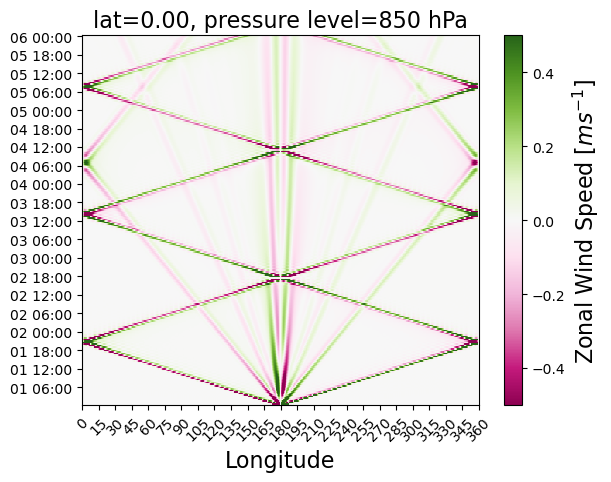

In [6]:
def Hovmoller(MyAx, field_DataArray, level, lat_val, MyCMAP):
    labelsize = 16
    times = field_DataArray.time
    lons = field_DataArray.lon

    field = field_DataArray[:, :, :, :].sel(lat=lat_val, plev=level, method="nearest")

    CF = MyAx.pcolormesh(lons, times, field, cmap=MyCMAP, vmin=-0.5, vmax=0.5)
    cb = plt.colorbar(CF, ax=MyAx)
    cb.set_label(r'Zonal Wind Speed [$m s^{-1}$]', size=labelsize)
    # MyAx.set_xticks([0, 30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330, 360])
    plt.xticks(rotation=45)
    MyAx.set_xticks(np.arange(0, 361, step=15))
    MyAx.set_xlabel("Longitude", size=labelsize)
    MyAx.yaxis.set_major_locator(HourLocator(interval=6))
    MyAx.yaxis.set_major_formatter(DateFormatter("%d %H:%M"))
    MyAx.set_title(f"lat={field.lat:.2f}, pressure level={level} hPa", size=labelsize)


# figure and axes
plt.figure(1)
hovmoller_ax = plt.axes()

# parameters
myLevel = 850
lat_value = 0

Hovmoller(hovmoller_ax, U_interp_da, myLevel, lat_value, 'PiYG')
# plt.savefig('U-Hovmoller-plev-850-More-Ticks.png', dpi=250)

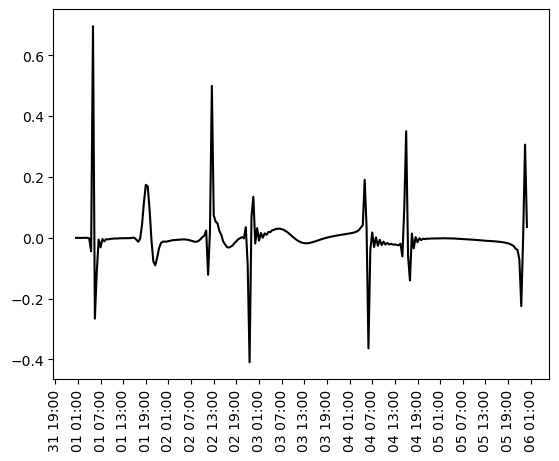

In [7]:
plt.figure(2)
tseries_ax = plt.axes()
tseries_ax.plot(U_interp_da.time, U_interp_da[:, :, :, :].sel(plev=850, lat=0, lon=225, method="nearest"), color='black')
tseries_ax.xaxis.set_major_locator(HourLocator(interval=6))
tseries_ax.xaxis.set_major_formatter(DateFormatter("%d %H:%M"))
plt.xticks(rotation=90)
plt.show()

Text(0.5, 1.0, 'Time=01 09:00')

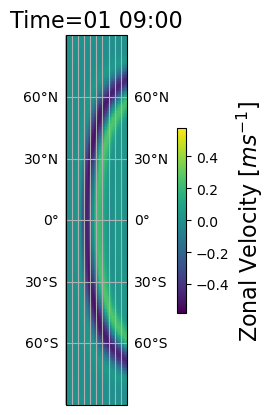

In [8]:
import cartopy.crs as ccrs
import matplotlib.ticker as mticker
from cartopy.mpl.ticker import LongitudeFormatter

zoomed_time_ind = 17
GeoFig = plt.figure(3)
GeoAx = plt.axes(projection=ccrs.PlateCarree())
U_CF = GeoAx.pcolormesh(U_interp_da.lon, U_interp_da.lat, U_interp_da[zoomed_time_ind, :, :, :].sel(plev=850, method="nearest"), 
                      transform=ccrs.PlateCarree())
Geo_cb = GeoFig.colorbar(U_CF, ax=GeoAx, shrink=0.5, pad=0.1)
Geo_cb.set_label(r'Zonal Velocity [$m s^{-1}$]', size=16)
GeoAx.set_extent([90, 120, -90, 90])
gl = GeoAx.gridlines(draw_labels=True)
gl.bottom_labels = False
gl.top_labels = False
gl.xlocator = mticker.FixedLocator(np.arange(90, 121, step=3))
GeoAx.set_title(f'Time={time_dt[zoomed_time_ind].strftime("%d %H:%M")}', size=16)
# plt.savefig("U-Zoomed-Spatial.png", dpi=250)

Text(0.5, 1.0, '06:30')

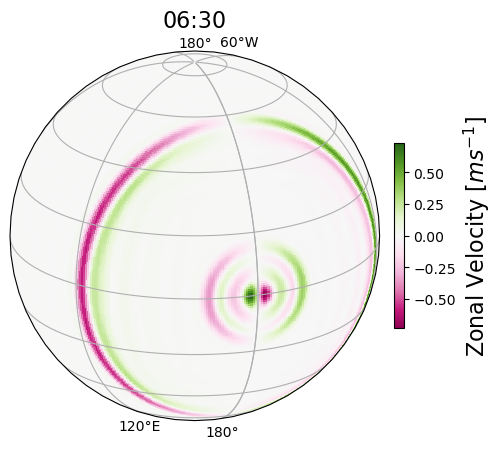

In [55]:
from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import MaxNLocator

Full_time_ind = 3
t2 = Full_time_ind+3
t3 = Full_time_ind+9

FullFig = plt.figure(4)
FullAx = plt.axes(projection=ccrs.Orthographic(central_longitude=160, central_latitude=20))
Full_CF = FullAx.pcolormesh(U_interp_da.lon, U_interp_da.lat, U_interp_da[t3, :, :, :].sel(plev=850, method="nearest"), 
                            transform=ccrs.PlateCarree(), cmap='PiYG')
Full_cb = FullFig.colorbar(Full_CF, ax=FullAx, shrink=0.5, pad=0.03)
Full_cb.set_label(r'Zonal Velocity [$m s^{-1}$]', size=16)
Full_gl = FullAx.gridlines(draw_labels=True)
Full_gl.xlines = True
Full_gl.ylines = True
# Full_gl.top_labels = False
# gl.xlocator = mticker.FixedLocator(np.arange(90, 121, step=3))
FullAx.set_title(f'{time_dt[t3].strftime("%H:%M")}', size=16)
# plt.savefig("Full_1.png", dpi=250)
# plt.savefig("Full_2.png", dpi=250)
# plt.savefig("Full_3.png", dpi=250)

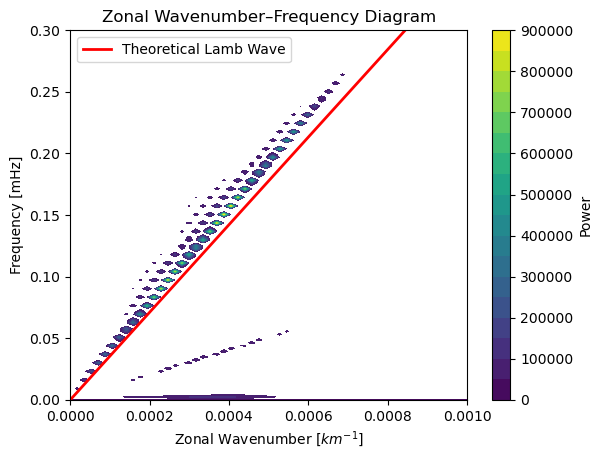

In [57]:
from scipy.fft import rfft2, fftfreq, rfftfreq

x = ds.U850.sel(lat=0)
x_anom = x - x.mean(dim='time')
x_fft = rfft2(x_anom)
nt, nx = x_anom.shape
dt = 1800  # output timestep (seconds)
dx = 111*1000  # horizontal grid spacing at the equator in meters
freq = fftfreq(nt, d=dt)
wavenumber = rfftfreq(nx, d=dx) * 1e3  # km^-1
power = np.abs(x_fft)**2

# cs
g = 9.81  # m s^-2
T0 = 275
Rd = 287
cp = 1004
cv = 717
gamma = cp / cv
kappa = Rd / cv
H = (Rd * T0) / g
Nsqr = (kappa * g) / H
N = np.sqrt(Nsqr)
cs = np.sqrt(gamma * Rd * T0) / 1000  # km s^-1
wavenumber_m = wavenumber / 1000
omega = (N * wavenumber_m) / np.sqrt(wavenumber_m**2 + (1/(4*H**2)))

# Plot
plt.figure(2)
plt.contourf(wavenumber, freq*1e3, power, levels=20)
plt.plot(wavenumber, omega*1e3, 'r-', label='Theoretical Lamb Wave', linewidth=2)
plt.xlabel(r"Zonal Wavenumber [$km^{-1}$]")
plt.ylabel("Frequency [mHz]")
plt.xlim((0, 0.001))
plt.ylim((0, 0.3))
plt.title("Zonal Wavenumber–Frequency Diagram")
plt.colorbar(label='Power')
plt.legend()
plt.show()

In [51]:
msqr

0.004416280377282114